# python

# 0. projekt

Vezesse le a 

$$
y'+y=2e^{3t}-1
$$

kde megoldását kézzel. 

Oldja meg a `dsolve` függvény segítségével is. 

Ábrázolja az egyenlet vektormezejét a $[-3,3] \times [-3,10]$-en és rajzoltassa rá az $y(-3)=-2, y(-3)=-1, y(-3)=0$ kezdeti értékekhez tartozó megoldásokat is.

## Kézi megoldás

Ez egy elsőrendű, lineáris kde. A homogén megoldása, valamilyen $C$-re:

$$
y(t) = Ce^{-t}\ \ \ \ C \in \mathbb R
$$

Ezért az inhom. mo.-t a konstans variálásának megfelelően, az alábbi alakban keressük:

$$
y(t) = C(t)e^{-t}
$$

Ezt behelyettesítve az eredeti egyenletbe:

$$
\begin{gather*}
C(t)'e^{-t} - C(t)e^{-t} + C(t)e^{-t} = 2e^{3t}-1 \\
C(t)'e^{-t} = 2e^{3t}-1 \\
C(t)' = e^{t}(2e^{3t}-1) \\
C(t)' = 2e^{4t}- e^{t} \ \ \ \ \  \text{integrálva} \\
C(t) =  \frac{e^{4t}}{2} - e^{t} + c \ \ \ \ c \in \mathbb R
\end{gather*}
$$

Visszahelyettesítve:
 

$$
y(t)=\left( \frac{e^{4t}}{2} - e^{t} + c\right) e^{-t} =
\frac{e^{3t}}{2} - 1 + ce^{-t}\ \ \ \ \ \ \ \ \ c \in \mathbb R
$$





## dsolve megoldás

In [1]:
# https://docs.sympy.org/latest/guides/solving/solve-ode.html
# from sympy import Function, Symbol, exp, dsolve, diff, Eq
# sympy started at about 2006-07: https://github.com/sympy/sympy/wiki/Release-Notes-Old

import sympy as sp
t = sp.symbols("t")
y = sp.symbols("y", cls=sp.Function)
the_eq = sp.Eq(y(t).diff(t)+y(t), 2*sp.exp(3*t)-1) # Eq(lhs, rhs)
gen_sol = sp.dsolve(the_eq)
print(gen_sol.rhs)



C1*exp(-t) + exp(3*t)/2 - 1


## Vektormező + megoldások

explicit alakra hozva:
$$
y' = 2e^{3t}-1-y = f(t, y)
$$

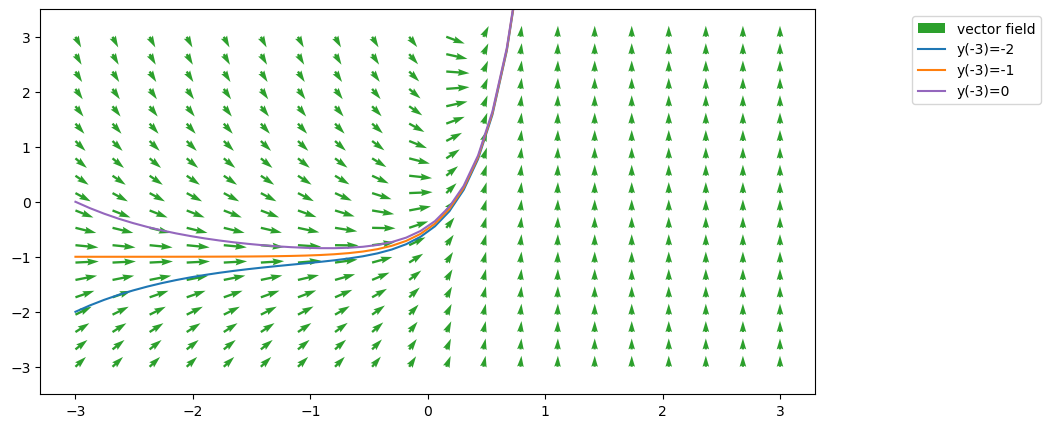

In [2]:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html
# https://matplotlib.org/stable/gallery/color/named_colors.html
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=10,5


T, Y = np.meshgrid(np.linspace(-3,3,20), np.linspace(-3,3,20))
DT = np.ones(np.shape(T))
DY = 2*np.exp(3*T)-1-Y
L = np.sqrt(DT**2 + DY**2)

ax = plt.subplot()
#plt.quiver(T, Y, DT / L, DY / L, color="tab:green", width=0.002) # szemmel láthatóan rosszat ad

plt.quiver(T,Y, DT/L, DY/L, 
  units='xy', angles='xy', scale_units='xy', scale=5.0, 
  color="tab:green",           
)


y0 = [-2, -1, 0]
part_sol1 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[0]}).rhs)
part_sol2 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[1]}).rhs)
part_sol3 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[2]}).rhs)


xx = np.linspace(-3,3);
ax.plot(xx, part_sol1(xx), color="tab:blue")
ax.plot(xx, part_sol2(xx), color="tab:orange")
ax.plot(xx, part_sol3(xx), color="tab:purple")

plt.legend(
  ["vector field", "y(-3)=-2", "y(-3)=-1", "y(-3)=0"], 
  bbox_to_anchor=(1.3, 1.0)
)
plt.ylim(-3.5, 3.5)
plt.show()
